In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Load the dataset
df=pd.read_csv('/content/sample_data/Telco-Customer-Churn.csv')
# Display the data
df

,CustomerID,Gender,Age_Group,Marital Status,Dependents,Tenure(Months),PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,Adult,Married,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,Adult,Single,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,Adult,Single,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,Adult,Single,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,Adult,Single,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Adult,Married,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,Adult,Married,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,Adult,Married,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Senior,Married,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
# Check data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   Age_Group         7043 non-null   object 
 3   Marital Status    7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure(Months)    7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Check for missing values
print(df.isnull().sum())

CustomerID          0
Gender              0
Age_Group           0
Marital Status      0
Dependents          0
Tenure(Months)      0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Get summary statistics of numerical columns (Tenure, MonthlyCharges, TotalCharges)
display(df.describe())

,Tenure(Months),MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.377396,64.761692,2279.990835
std,24.551845,30.090047,2266.552744
min,1.000000,18.250000,18.800000
25%,9.000000,35.500000,398.900000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [11]:
# Check for duplicate rows and drop them if any exist
df = df.drop_duplicates()

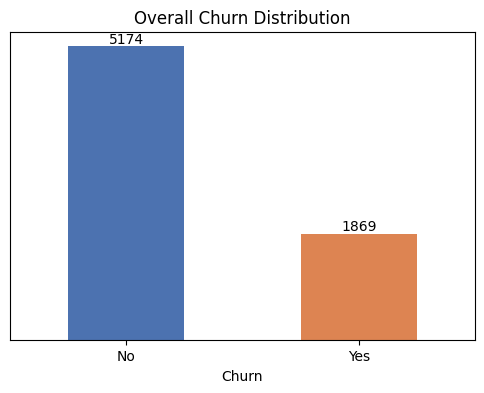

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [27]:
import matplotlib.pyplot as plt

# Plot Churn Distribution
plt.figure(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
churn_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'])

plt.title('Overall Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('') # Remove y-axis label
plt.yticks([]) # Remove y-axis ticks
plt.xticks(rotation=0)

# Add data labels
for index, value in enumerate(churn_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()
# Print exact percentages
print(df['Churn'].value_counts(normalize=True) * 100)

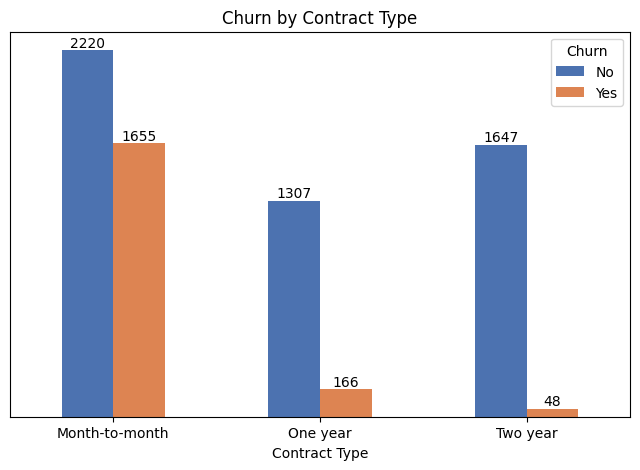

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot Contract Type vs Churn
plt.figure(figsize=(8, 5))
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
ax = contract_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=plt.gca())

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('') # Remove y-axis label
plt.yticks([]) # Remove y-axis ticks
plt.xticks(rotation=0)
plt.legend(title='Churn')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

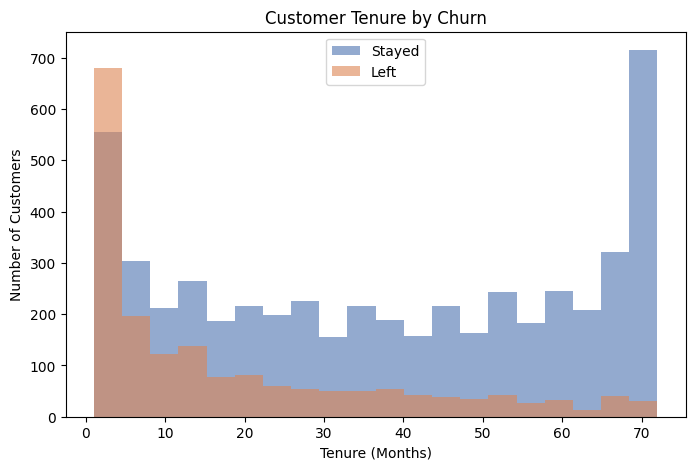

In [22]:
# Plot Tenure vs Churn
plt.figure(figsize=(8, 5))
plt.hist(df[df['Churn'] == 'No']['Tenure(Months)'], bins=20, alpha=0.6, label='Stayed', color='#4C72B0')
plt.hist(df[df['Churn'] == 'Yes']['Tenure(Months)'], bins=20, alpha=0.6, label='Left', color='#DD8452')

plt.title('Customer Tenure by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

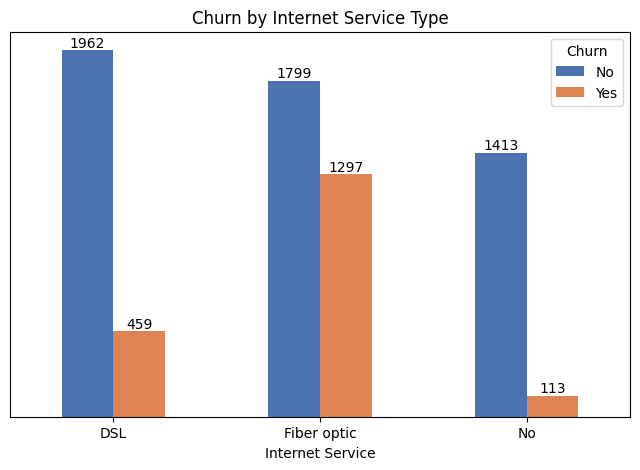

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Internet Service vs Churn
plt.figure(figsize=(8, 5))
is_churn = pd.crosstab(df['InternetService'], df['Churn'])
ax = is_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=plt.gca())
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('') # Remove y-axis label
plt.yticks([]) # Remove y-axis ticks
plt.xticks(rotation=0)
plt.legend(title='Churn')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

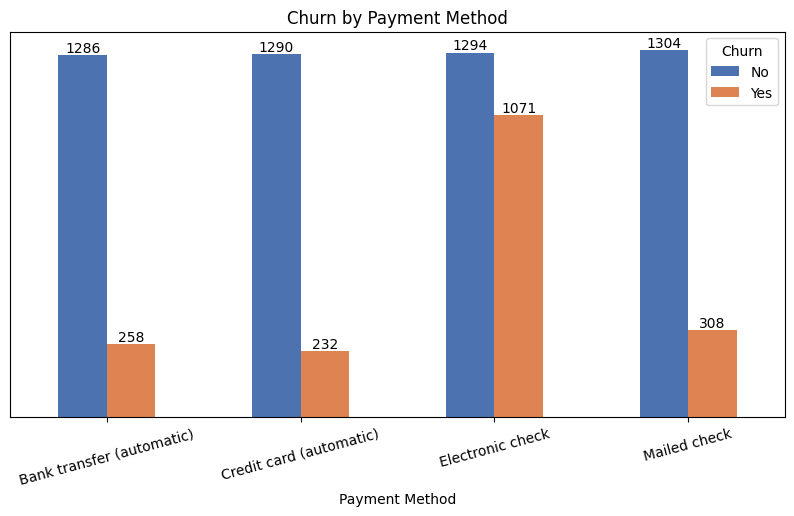

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Payment Method vs Churn
plt.figure(figsize=(10, 5))
pm_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])
ax = pm_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=plt.gca())
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('') # Remove y-axis label
plt.yticks([]) # Remove y-axis ticks
plt.xticks(rotation=15) # Rotated labels so they fit!
plt.legend(title='Churn')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

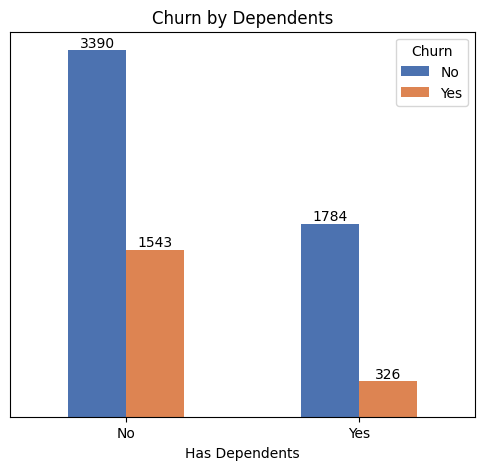

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Dependents vs Churn
plt.figure(figsize=(6, 5))
dep_churn = pd.crosstab(df['Dependents'], df['Churn'])
ax = dep_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=plt.gca())
plt.title('Churn by Dependents')
plt.xlabel('Has Dependents')
plt.ylabel('') # Remove y-axis label
plt.yticks([]) # Remove y-axis ticks
plt.xticks(rotation=0)
plt.legend(title='Churn')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()